## K-NN

**K-Nearest Neighbors (KNN)** é um algoritmo de aprendizado de máquina simples, versátil e não paramétrico, usado para tarefas de classificação e regressão. Ele opera com base no princípio da similaridade, prevendo o rótulo ou valor de um ponto de dados com base na classe majoritária ou na média de seus *k* vizinhos mais próximos no espaço de características. O KNN é intuitivo e eficaz para conjuntos de dados pequenos ou quando a interpretabilidade é fundamental.

### Conceitos Importantes

- **Aprendizado Baseado em Instâncias**: O KNN é um algoritmo de aprendizado preguiçoso, o que significa que não requer uma fase de treinamento explícita. Ele armazena todo o conjunto de dados e realiza os cálculos no momento da predição.

- **Métrica de Distância**: O algoritmo mede a distância entre os pontos de dados para identificar os vizinhos mais próximos. As métricas comuns incluem:

    - Distância Euclidiana: $ \displaystyle \sqrt{\sum_{i=1}^n (x_i - y_i)^2} = \displaystyle \sqrt{ (x_0 - y_0)^2 + (x_1 - y_1)^2 + (x_2 - y_2)^2 + \cdots + (x_n - y_n)^2 }  $
    - Distância de Manhattan: $ \displaystyle \sum_{i=1}^n \|x_i - y_i\| $
    - Distância de Minkowski: $ \displaystyle \left( \sum_{i=1}^n \|x_i - y_i\|^p \right)^{1/p} $

- **Valor K**: O número de vizinhos considerados. Um valor pequeno de *k* pode ser sensível a ruídos - *overfitting* -, enquanto um valor grande de *k* suaviza as previsões, mas pode diluir padrões - *underfitting* -.

- **Regra de Decisão**:

    - **Classificação**: A classe majoritária entre os *k* vizinhos determina a classe prevista.

    - **Regressão**: A média (ou média ponderada) dos valores dos *k* vizinhos é utilizada.

### Fundamentos Matemáticos

O KNN utiliza cálculos de distância para encontrar vizinhos. Para um ponto de dados \( x \), o algoritmo:

1. Calcula a distância até todos os pontos no conjunto de dados usando uma métrica escolhida (por exemplo, distância euclidiana).

2. Seleciona os *k* pontos mais próximos.

3. Para classificação, atribui a classe com o maior número de votos entre os *k* vizinhos. Para regressão, calcula a média dos seus valores.

### Exemplo: Classificação

Dado um conjunto de dados $ D = \{(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)\} $, onde $ x_i $ é um vetor de características e $ y_i $ é o rótulo da classe, preveja a classe de um novo ponto $ x $:

- Calcule as distâncias $ d(x, x_i) $ para todos os $ i $.

- Ordene as distâncias e selecione as *k* menores.

- Conte os rótulos de classe desses *k* pontos e atribua a classe majoritária a $ x $.

### KNN Ponderado

No KNN ponderado, os vizinhos contribuem para a previsão com base na distância entre eles. Vizinhos mais próximos têm maior influência, geralmente ponderada pelo inverso da distância:

$$ w_i = \frac{1}{d(x, x_i)} $$

Para regressão, a previsão é:

$$ \hat{y} = \frac{\sum_{i=1}^k w_i y_i}{\sum_{i=1}^k w_i} $$

### Visualizando o KNN

Para ilustrar, considere um conjunto de dados 2D com duas classes (círculos azuis e triângulos vermelhos). Para um novo ponto (estrela verde), o KNN identifica os *k* pontos mais próximos e atribui a classe majoritária.

![Exemplo de Classificação KNN](https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/KnnClassification.svg/1920px-KnnClassification.svg.png)
<center>
Figura: KNN com $k=3$. A estrela verde é classificada com base na classe majoritária (círculos azuis) entre seus três vizinhos mais próximos. Já com $k=5$, a classificação muda.
</center>

Para regressão, imagine prever um valor contínuo (por exemplo, o preço de uma casa) com base na média dos preços das *k* casas mais próximas.

### Fronteira de Decisão

A fronteira de decisão do KNN não é linear e depende da distribuição dos dados. Abaixo, um exemplo de fronteiras de decisão para diferentes valores de *k*:

![Fronteira de Decisão do KNN](https://scikit-learn.org/stable/_images/sphx_glr_plot_classification_001.png)
<center>
Figura: Fronteiras de decisão para k=1, k=5 e k=15. Valores menores de k resultam em fronteiras mais complexas, enquanto valores maiores de k as suavizam.
</center>

### Prós e Contras do KNN

#### Prós
- **Simplicidade**: Fácil de entender e implementar.

- **Não Paramétrico**: Não faz suposições sobre a distribuição dos dados, sendo adequado para dados não lineares.

- **Versatilidade**: Funciona tanto para classificação quanto para regressão.

- **Adaptabilidade**: Pode lidar com problemas multiclasse e diferentes tipos de dados com métricas de distância apropriadas.

#### Contras
- **Custo Computacional**: Lento para grandes conjuntos de dados, pois requer o cálculo das distâncias para cada previsão.

- **Consumo Intensivo de Memória**: Armazena todo o conjunto de dados, o que pode ser problemático para big data.

- **Sensível a Ruídos**: Valores discrepantes ou características irrelevantes podem degradar o desempenho.

- **Maldição da Dimensionalidade**: O desempenho cai em espaços de alta dimensionalidade devido à escassez de dados.

- **Escolha de K**: Requer um ajuste cuidadoso de *k* e da métrica de distância para equilibrar viés e variância.

### Implementação do KNN

Abaixo estão duas implementações do KNN: uma do zero e outra usando a biblioteca scikit-learn do Python.

#### Do Zero

Esta implementação inclui um classificador KNN básico usando a distância euclidiana.

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

class KNNClassifier:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        # Compute Euclidean distances
        distances = [np.sqrt(np.sum((x - x_train)**2)) for x_train in self.X_train]
        # Get indices of k-nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        # Get corresponding labels
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        # Return majority class
        most_common = max(set(k_nearest_labels), key=k_nearest_labels.count)
        return most_common

# Example usage

# Generate synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and predict
knn = KNNClassifier(k=3)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")

Accuracy: 1.00


#### Usando Scikit-Learn

Accuracy: 0.90


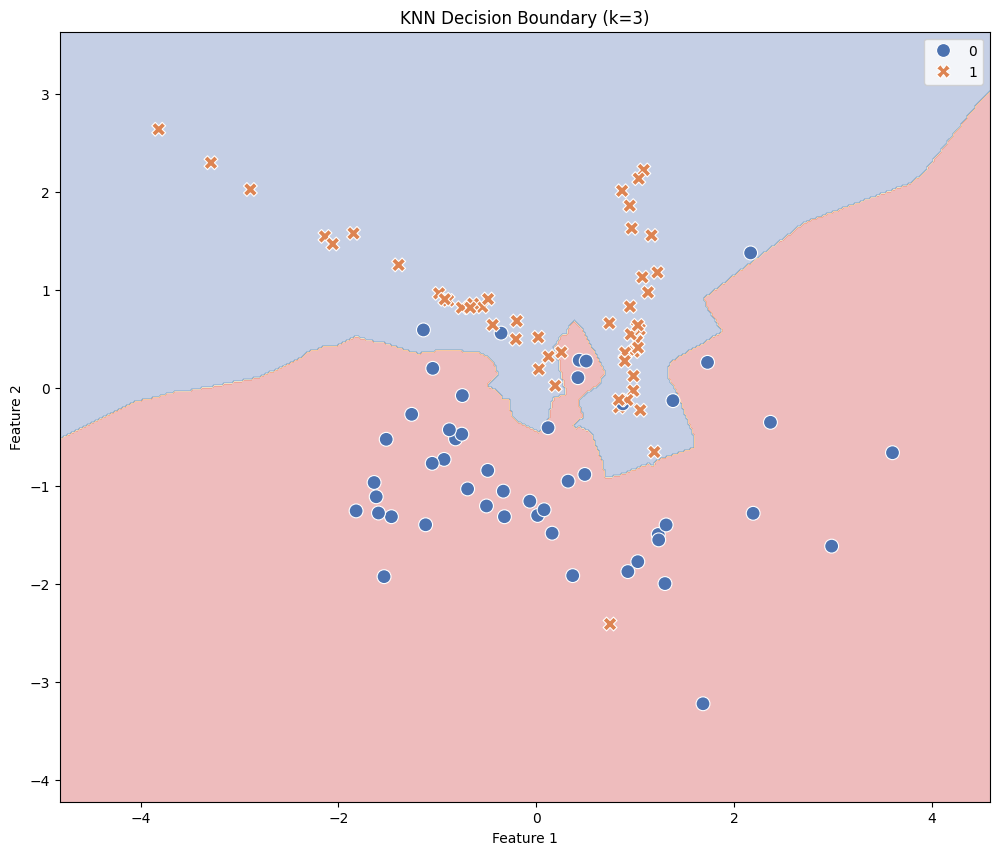

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import seaborn as sns

plt.figure(figsize=(12, 10))

# Generate synthetic dataset
X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=2, random_state=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
predictions = knn.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}")

# Visualize decision boundary
h = 0.02  # Step size in mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.3)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, style=y, palette="deep", s=100)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary (k=3)")
plt.show()
plt.close()

### Exercício

- Implemente um K-NN, usando pipeline para o dataset iris;
    - use k = 1, 3, 10;
    - use um gridsearch para achar o melhor k.
- Imprima o gráfico das fronteiras de decisões;
- Calcule e compare as métricas de acertos: acurácia, precisão, recall e F1-Score.